# Training and forecasting with the AIFS-ENS: the full Anemoi workflow

**Author**: ECMWF ML course team

*This notebook was last tested and operational on 13/07/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was developed for the DestinE [2026 Machine Learning for Earth System Modelling Course](https://learning.ecmwf.int/course/view.php?id=99) and accompanies module 7, which focuses specifically on Anemoi. We already ran notebooks that used Anemoi in e.g. [module 3](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m3/using_era5_anemoi.ipynb), [module 4](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m4/run_AIFS_v2.0.ipynb) and [module 5](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m5/run_AIFS_ENS_v2.0.ipynb). In those notebooks, we prepared data for training, and ran inference with models that have been trained using Anemoi. Here, we will put the two pieces together, and add the missing piece in the middle: Training the actual AI weather model. That is, we will go through a typical Anemoi workflow: Build a dataset, train an ensemble model, and run it to forecast today's weather.

This notebook builds on the *Hands-on: Training the AIFS-ENS with Anemoi* materials from ECMWF's [live DestinE ML training course](https://github.com/ecmwf-training/2026-ml-destine-training), which we have restructured and extended into the single, end-to-end workflow you see here.
<!-- ::: -->

<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
**Important note:** this notebook trains a neural network and therefore requires GPU access (tested on an NVIDIA A100) and several GB of writeable disk space. It will not run on a CPU-only machine in reasonable time. If you have access to GPUs (e.g. on ECMWF's ATOS HPCF, or a cloud GPU runtime), run it there. Depending on your system, small adjustments may be needed.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/main/m7/training_aifs-ens_v1.0_solved.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m7/training_aifs-ens_v1.0_solved.ipynb)
<!-- ::: -->

# Introduction

In modules 4 and 5 you *ran* pre-trained AIFS models. But where do such models come from? Producing a data-driven forecast model involves three distinct stages, which can each be handled by am Anemoi package you encountered in the webinar series:

| Stage | Anemoi package | What it does |
|---|---|---|
| 1. Build a dataset | `anemoi-datasets` | turn raw meteorological archives into a training-ready, chunked zarr archive with pre-computed statistics |
| 2. Train a model | `anemoi-training` | configure and run the training loop that fits a graph-transformer to that dataset |
| 3. Run a forecast | `anemoi-inference` | load the trained checkpoint and roll it forward from real initial conditions |

In this notebook, we cover all three steps, with the aim to train and run an *ensemble* model, akin to AIFS-ENS v1.0.


## In this notebook
You will:
- assemble an Anemoi training dataset from the public ERA5 catalogue;
- read and *write* the Anemoi training configuration, and explain the ingredients within Anemoi that turn a deterministic model into an ensemble one (`GraphEnsForecaster`, noise injection, the CRPS loss);
- connect the model's architecture to the graph-neural-network and transformer ideas from module 2;
- run your own checkpoint to forecast today's weather, and critically assess where a small, briefly-trained model succeeds and fails.

> ⚠️ **In this notebook, we train a deliberately small toy model.** To keep this notebook short enough to run on small resources in a reasonable amount of time, we will make the model much smaller, and train it much shorter, than the actual AIFS-ENS v1.0 model. This means the forecasts in Part 3 will be recognisable but visibly imperfect. We are here therefore exploring the effect of data and training budget, rather than creating the best possible model.

**Resources.** [General Anemoi documentation](https://anemoi.readthedocs.io/) · [Anemoi's CRPS-based training guide](https://anemoi.readthedocs.io/projects/training/en/latest/user-guide/kcrps-set-up.html) · [Lang et al. 2024, *AIFS-CRPS*](http://arxiv.org/abs/2412.15832)

## Prepare your environment

This notebook requires (see `m7/requirements.txt` for exact pins):
- Python 3.11 or 3.12, an Ampere-or-newer GPU, and several GB of writeable disk
- `anemoi-training`, `anemoi-datasets`, `anemoi-models`, `anemoi-graphs`, `anemoi-inference`
- `torch`, `flash-attn` (the transformer processor uses windowed attention — a pure-PyTorch fallback rapidly runs out of memory)
- `mlflow`, `earthkit-regrid`, `ecmwf-opendata`, `cartopy`, `matplotlib`

The cell below installs everything that is not already available.

# 0. Install dependencies

In [1]:
import importlib.util as _u

_needed = ["anemoi.training", "anemoi.datasets", "anemoi.inference", "flash_attn", "cartopy"]

# Check if any of these are absent
def _absent(m):
    try:
        return _u.find_spec(m) is None
    except ModuleNotFoundError:
        return True

_missing = any(_absent(m) for m in _needed)

if _missing:
    %pip install -q -r https://raw.githubusercontent.com/ecmwf-training/2026-ml-esm-training/main/m7/requirements.txt

    # flash-attn ships as a torch/CUDA/Python-specific wheel; install a prebuilt one (no compile).
    try:
        import flash_attn  # noqa: F401
    except Exception:
        import sys, subprocess
        _base = "https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.4.post1"
        _wheels = {
            (3, 11): f"{_base}/flash_attn-2.7.4.post1+cu12torch2.6cxx11abiFALSE-cp311-cp311-linux_x86_64.whl",
            (3, 12): f"{_base}/flash_attn-2.7.4.post1+cu12torch2.6cxx11abiFALSE-cp312-cp312-linux_x86_64.whl",
        }
        _w = _wheels.get(sys.version_info[:2])
        if _w:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", _w], check=True)
        else:
            print("No prebuilt flash-attn wheel for this Python; see the flash-attention README to build it.")
else:
    print("Environment already set up — skipping installation.")

Environment already set up — skipping installation.


In [2]:
import os, sys
from pathlib import Path
import torch

# If supporting files (configs/ and helpers.py) are not present (won't be on 
# Colab/Kaggle/Binder), fetch them from the course repo.
if not Path("configs").is_dir() or not Path("helpers.py").exists():
    import subprocess, shutil
    _repo = "https://github.com/ecmwf-training/2026-ml-esm-training.git"
    _tmp = Path("/tmp/ecmwf-2026-ml-esm-training")
    if not _tmp.exists():
        subprocess.run(["git", "clone", "--depth", "1", _repo, str(_tmp)], check=True)
    for _item in ("configs", "helpers.py"):
        _src, _dst = _tmp / "m7" / _item, Path(_item)
        if _src.exists() and not _dst.exists():
            (shutil.copytree if _src.is_dir() else shutil.copy)(_src, _dst)
    print("Fetched configs/ and helpers.py from the course repo.")

# Make sure the anemoi-* console scripts (installed next to this Python) are on PATH,
# so the subprocess calls below work regardless of how the kernel was launched.
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ.get("PATH", "")

# Working directories (everything this notebook produces lives under the m7 folder)
WORKDIR = Path.cwd()
DATA_DIR = WORKDIR / "data"
DATA_DIR.mkdir(exist_ok=True)
CONFIG_DIR = WORKDIR / "configs"

# anemoi-training discovers config groups (model/, graph/, training/, ...) via this env var
os.environ["ANEMOI_CONFIG_PATH"] = str(CONFIG_DIR)
os.environ["ANEMOI_BASE_SEED"] = "42"

print("Working dir :", WORKDIR)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

/home/user/virtualenv/m7-anemoi/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Working dir : /home/user/2026-ml-esm-training/m7
CUDA available: True
GPU         : (CUDA GPU)


# Part 1 · Build a training dataset with `anemoi-datasets`

### Under the hood: what is a "training-ready" dataset?

As you remember from  module 3, we prefer not to train neural weather models e.g. on GRIB messages. Instead,  in **[Anemoi training-ready ERA5 dataset](https://www.ecmwf.int/en/about/media-centre/aifs-blog/2025/introducing-anemoi-training-ready-version-era5)**, we created a zarr store with

- a **fixed set of variables**, merged into one array,
- a **uniform 6-hourly** time axis (no gaps),
- **pre-computed normalisation statistics** (mean/std/min/max) stored in the metadata, and
- **chunking along time** for fast, parallel random access.

`anemoi-datasets` builds these. You give it a *recipe* (a YAML describing where the data comes from and which dates to cover), and `anemoi-datasets create` streams the source, assembles the array, computes statistics, and writes the zarr.

### Our recipe: subset the public O96 catalogue

For an open and rapidly-accessed data source, we access the `anemoi-dataset` *source*, which lets a recipe treat an *existing* Anemoi dataset as its input. We point it at the public catalogue dataset you met in module 3 —

`https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr`

— and subset it in two ways to keep our toy model small and fast:

1. In time: We subset the training dataset to a couple of months instead of 45 years (`dates:` block).
2. In variables: We only extract a handful of fields for our model to predict and use as inputs (`select:`).

The O96 grid (~40 000 points, ≈1°) is kept as-is.

#### Task 1: choose the variables

The list below is the set of variables our model needs. It needs three kinds of field:

- **prognostic** fields the model predicts and feeds back to itself: `2t` (2 m temperature), `tcw` (total column water), geopotential `z` at several pressure levels, and temperature at 850 hPa `t_850`;
- **forcings** that are known for any date (solar `insolation`, and sine/cosine encodings of latitude, longitude, day-of-year and time-of-day);
- **static** fields, which are constant in time: land–sea mask `lsm`, surface geopotential/orography `z`, sub-grid orography `sdor`/`slor`.

Complete the `SELECT` list with the missing variables. Everything downstream (the model's input/output channels) follows from this choice.

In [3]:
# Task 1: the variables to extract from the catalogue for our toy model.
SELECT = [
    "z_1000", "z_500", "z_700", "z_300", "2t", "t_850", "tcw", "z_250",    # prognostic
    "lsm", "z", "sdor", "slor",                                            # static
    "cp", "tp",                                                            # diagnostic (predicted, not fed back)
    "cos_latitude", "cos_longitude", "sin_latitude", "sin_longitude",      # forcings
    "cos_julian_day", "cos_local_time", "sin_julian_day", "sin_local_time",
    "insolation",
]

# The date window. Training uses Jan-Feb, validation uses March (set later in the training config).
START, END = "2020-01-01", "2020-03-31"

print(f"{len(SELECT)} variables, {START} - {END}")

23 variables, 2020-01-01 - 2020-03-31


Now let us use these definitions to build our recipe. As you know from the webinars, these recipes are configurations stored in YAML files. The cell below builds `recipe.yaml` from the chosen dates and selected variables.

In [4]:
import yaml

recipe = {
    "dates": {"start": START, "end": END, "frequency": "6h"},
    "input": {
        "anemoi-dataset": {
            "dataset": "https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr",
            "select": SELECT,
        }
    },
}

RECIPE_PATH = WORKDIR / "recipe.yaml"
RECIPE_PATH.write_text(yaml.safe_dump(recipe, sort_keys=False))
print(RECIPE_PATH.read_text())

dates:
  start: '2020-01-01'
  end: '2020-03-31'
  frequency: 6h
input:
  anemoi-dataset:
    dataset: https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr
    select:
    - z_1000
    - z_500
    - z_700
    - z_300
    - 2t
    - t_850
    - tcw
    - z_250
    - lsm
    - z
    - sdor
    - slor
    - cp
    - tp
    - cos_latitude
    - cos_longitude
    - sin_latitude
    - sin_longitude
    - cos_julian_day
    - cos_local_time
    - sin_julian_day
    - sin_local_time
    - insolation



### Build the dataset

`anemoi-datasets create` runs the pipeline: it opens the source, iterates the requested dates, writes each field into the zarr, then computes and stores the statistics. You can run this in your terminal, but we here  run it from our Jupyter Notebook with a subprocess call to keep everything in one place. 

For our two-month, 23-variable subset, this operation takes a few minutes and produces a dataset of a few hundred MB. (We skip the build if the dataset already exists, so re-running the notebook is cheap.)

In [5]:
import subprocess, sys

DATASET_PATH = DATA_DIR / "era5-o96-2020JFM.zarr"

if (DATASET_PATH / ".zattrs").exists():
    print(f"Dataset already exists at {DATASET_PATH} — skipping build.")
else:
    print("Building dataset (this streams the subset from the catalogue; ~10-15 min)...")
    proc = subprocess.run(
        ["anemoi-datasets", "create", str(RECIPE_PATH), str(DATASET_PATH)],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
    )
    print(proc.stdout[-2000:])
    print("Return code:", proc.returncode)

Building dataset (this streams the subset from the catalogue; ~10-15 min)...


JFM.zarr: 16it [00:00, 3889.47it/s]
2026-07-13 17:00:25 INFO Total size: 462.2 MiB
2026-07-13 17:00:25 INFO Total number of files: 407
2026-07-13 17:00:25 INFO 🏁 Task finalise((),{}) completed (0:00:00.050978)
2026-07-13 17:00:25 INFO 🎬 Task init_additions((),{}) starting
2026-07-13 17:00:25 WARNING No delta found in kwargs, no additions will be computed.
2026-07-13 17:00:25 INFO 🏁 Task init_additions((),{}) completed (0:00:00.000124)
2026-07-13 17:00:25 INFO 🎬 Task run_additions((),{}) starting
2026-07-13 17:00:25 WARNING No delta found in kwargs, no additions will be computed.
2026-07-13 17:00:25 INFO 🏁 Task run_additions((),{}) completed (0:00:00.000079)
2026-07-13 17:00:25 INFO 🎬 Task finalise_additions((),{}) starting
2026-07-13 17:00:25 WARNING No delta found in kwargs, no additions will be computed.

Computing size of /home/user/2026-ml-esm-training/m7/data/era5-o96-2020JFM.zarr: 0it [00:00, ?it/s]
Computing size of /home/user/2026-ml-esm-training/m7/data/era5-o96-2020JFM.zarr: 

### Inspect what you built

The dataset is now a self-contained Anemoi zarr. Let's open it the same way you did in module 3 and check its shape, variables and statistics. The array shape is `(time, variables, ensemble, gridpoints)` — the `ensemble` axis is 1 here (ERA5 is a single realisation); our *model* will create ensemble members later.

In [6]:
from anemoi.datasets import open_dataset

ds = open_dataset(str(DATASET_PATH))
print("shape (time, vars, ens, grid):", ds.shape)
print("dates:", ds.dates[0], "-", ds.dates[-1], f"({len(ds.dates)} steps, {ds.frequency})")
print("n variables:", len(ds.variables))
print("statistics keys:", list(ds.statistics.keys()))

shape (time, vars, ens, grid): (361, 23, 1, 40320)
dates: 2020-01-01T00:00:00 - 2020-03-31T00:00:00 (361 steps, 6:00:00)
n variables: 23
statistics keys: ['mean', 'stdev', 'maximum', 'minimum']


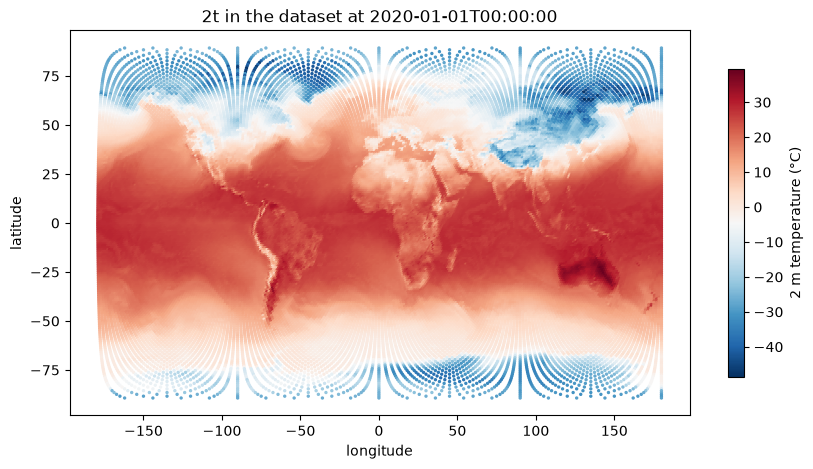

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Quick look at the first time step of 2m temperature on the O96 grid
lat = ds.latitudes
lon = np.where(ds.longitudes > 180, ds.longitudes - 360, ds.longitudes)
i2t = ds.variables.index("2t")
field = ds[0][i2t, 0]  # (gridpoints,)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(lon, lat, c=field - 273.15, s=2, cmap="RdBu_r")
fig.colorbar(sc, ax=ax, shrink=0.8, label="2 m temperature (°C)")
ax.set_title(f"2t in the dataset at {ds.dates[0]}")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.show()

# Part 2 · Train an ensemble model with `anemoi-training`

### Under the hood: what does the model look like?

Our model consists of two ideas from module 2, stitched together: It is a "graph-transformer", in the form of an encoder–processor–decoder:

- a **graph encoder** maps the ~40 000 irregular grid points onto a smaller regular *hidden mesh*, using message passing along graph edges. This uses the machinery we first saw in the m2 GNN notebook;
- a **transformer processor** then evolves that hidden state, using (windowed) self-attention so distant parts of the globe can influence each other. Here we will use code that we first saw in the m2 Transformer notebook;
- a **graph decoder** maps the processed hidden state back to the grid to produce the forecast.

`anemoi-graphs` builds the encoder/decoder graphs from the dataset's coordinates; `anemoi-models` assembles the network; `anemoi-training` fits it. The model forecasts one 6-hour step at a time and is rolled forward autoregressively.

### Under the hood: from deterministic to *ensemble* (CRPS) training

A deterministic model outputs one field per variable and is trained with a mean-squared-error loss. To make it an *ensemble* model we have to modify five coupled Anemoi components in the training pipeline:

| Component | Deterministic | Ensemble (CRPS) |
|---|---|---|
| Forecaster (training task) | `GraphForecaster` | `GraphEnsForecaster` |
| Distributed strategy | `DDPGroupStrategy` | `DDPEnsGroupStrategy` |
| Model | `AnemoiModelEncProcDec` | `AnemoiEnsModelEncProcDec` |
| Data module | `AnemoiDatasetsDataModule` | `AnemoiEnsDatasetsDataModule` |
| Loss | `WeightedMSELoss` | `AlmostFairKernelCRPS` |

These names will reappear in the config below, so it is worth knowing what each does:

- Forecaster (training task) — the PyTorch-Lightning module that wraps the model and defines what happens in a training step: run the model forward, compare against the truth and compute the loss. The ensemble version (`GraphEnsForecaster`) generates several members per step and aggregates their scores.
- Distributed strategy — how the work is split across GPUs. The ensemble version (`DDPEnsGroupStrategy`) additionally knows how to spread the members of one forecast across a group of GPUs and gather them back to compute the loss.
- Model — the neural network itself (the encoder–processor–decoder graph-transformer from above). The ensemble version (`AnemoiEnsModelEncProcDec`) adds the noise-injection machinery that lets one set of weights produce many members.
- Data module — feeds batches of initial conditions and targets to the forecaster. The ensemble version arranges the data so each member-group gets what it needs.
- Loss — the objective we minimise. A deterministic model uses (weighted) mean-squared error; an ensemble is instead scored with the CRPS (below), which rewards a distribution of members rather than a single value.

**How members differ.**
The ensemble model injects random noise into the network (`NoiseConditioning`): each member (which shares a set of weights) draws its own noise vector, which conditions the processor's normalisation layers (`ConditionalLayerNorm`). Same weights, same initial conditions, but different noise, gives different, plausible future states.

**The almost-fair CRPS loss.**
You'll remember from modules 5 and 6 that the Continuous Ranked Probability Score (CRPS) is a proper score for probabilistic forecasts: it rewards members that are both accurate and appropriately spread. Anemoi computes it in *kernel* form directly from the ensemble members: the mean distance between each member and the truth, minus half the mean distance between pairs of members (the second term is what credits spread).

Estimated this way from a finite number of members, the CRPS is slightly biased; it penalises a small ensemble for having too little spread, even when the underlying distribution is perfect. The *fair* CRPS (`fCRPS`) removes this finite-ensemble bias, so that a model is not pushed toward artificially over-spread forecasts just because we trained it with few members. Because the fully-fair estimator can be noisy to optimise, Anemoi blends it with the plain CRPS (`CRPS`), giving the *almost-fair* CRPS (`afCRPS`)

$$\text{afCRPS}_\alpha = \alpha\,\text{fCRPS} + (1-\alpha)\,\text{CRPS},$$

where $\alpha \in [0, 1]$ sets how "fair" the training signal is: $\alpha = 1$ is fully fair, $\alpha = 0$ is the plain (biased) CRPS, and values in between trade a little bias for a smoother, more stable gradient. We train with $\alpha = 1$. See [Lang et al. 2024](http://arxiv.org/abs/2412.15832) for the details.

### Building the training configuration

Let us now construct the training configuration. This again involves constructing a YAML file, but this time it is a bit more complex, because there are many options to select. `anemoi-training` is configured with [Hydra](https://hydra.cc/). Hydra is a framework for organising configurations, which works as follows: In our YAML, we will first set up a "top-level config", which selects a set of group default settings (which `model`, `graph`, `training`, ... preset to start from). These are loaded from the `configs/` directory in this module. Then, our YAML file will override specific values to tailor the config to the training at hand (here, our small ensemble-model setup).

The YAML file is two code cells down; you should recognise every ensemble ingredient. A few values are left for you to set.

#### Task 2 — set the ensemble ingredients

Fill in the three highlighted values:

- `MODEL_TARGET` — the *ensemble* model class (use the table above, and the fact that you can find Anemoi models in `anemoi.models.models.ModelName`);
- `ENSEMBLE_SIZE` — how many members each GPU generates per step (2 might be enough for our toy);
- `ALPHA` — the almost-fair CRPS trade-off (use `1.0`).

In [8]:
# Task 2: the ensemble ingredients
MODEL_TARGET  = "anemoi.models.models.AnemoiEnsModelEncProcDec"   # ensemble model class
ENSEMBLE_SIZE = 2                                                 # members per device
ALPHA         = 1.0                                              # almost-fair CRPS trade-off

# Training budget (kept small so the whole notebook runs in minutes)
MAX_STEPS = 150

print(f"model={MODEL_TARGET}\nensemble_size_per_device={ENSEMBLE_SIZE}\nalpha={ALPHA}\nmax_steps={MAX_STEPS}")

model=anemoi.models.models.AnemoiEnsModelEncProcDec
ensemble_size_per_device=2
alpha=1.0
max_steps=150


Now let us assemble the top-level training config in its own YAML file. You will see that this is becoming quite an extensive recipe, but you will hopefully recognise many elements from the webinars. Several key choices are commented for extra context, and your choices above are written in the relevant places.

**How the file is organised.** The config has two parts:

- a **`defaults:` list** at the top. This is the Hydra mechanism: each entry (`data: zarr`, `model: transformer_ens`, `training: ensemble`, ...) picks a ready-made preset from the matching sub-folder in `configs/` (`configs/model/transformer_ens.yaml`, and so on). Together they give a complete, working configuration before we change anything. `_self_` at the end means "apply my own overrides last".
- a set of **override sections** — `hardware`, `data`, `dataloader`, `datamodule`, `model`, `training`, `diagnostics` — where we change just the values we care about (paths, dataset name, ensemble size, loss, learning-rate schedule, ...). Anything we do not mention keeps its value from the preset.

So reading the file top-to-bottom: *pick the ensemble presets, then tweak them for our tiny toy run.*

In [9]:
# Define training config and write it into the configs/ search path.
config_yaml = f"""
defaults:
- data: zarr
- dataloader: native_grid
- datamodule: ens                # AnemoiEnsDatasetsDataModule (ensemble data loading)
- diagnostics: evaluation
- hardware: example
- graph: encoder_decoder_only    # GNN encoder + decoder around the transformer processor
- model: transformer_ens         # transformer processor with noise conditioning
- training: ensemble             # GraphEnsForecaster + DDPEnsGroupStrategy + CRPS loss
- _self_

config_validation: True

hardware:
  paths:
    data: {DATA_DIR}/
    output: /home/${{oc.env:USER}}/anemoi-output/
  files:
    dataset: {DATASET_PATH.name}
    graph: ens_o96.graph
  accelerator: auto
  num_gpus_per_ensemble: 1
  num_gpus_per_model: 1

data:
  resolution: o96
  timestep: 6h

dataloader:
  dataset:
    dataset: ${{hardware.paths.data}}/${{hardware.files.dataset}}
    select: {SELECT}
  batch_size:
    training: 2
    validation: 2
  limit_batches:
    training: 50
    validation: 10
  training:                        # train on Jan-Feb
    start: 2020-01-01
    end: 2020-02-29
  validation:                      # validate on March
    start: 2020-03-01
    end: 2020-03-31

datamodule:
  _target_: anemoi.training.data.datamodule.AnemoiEnsDatasetsDataModule

model:
  num_channels: 128
  model:
    _target_: {MODEL_TARGET}
  noise_injector:                # each member draws its own noise vector
    _target_: anemoi.models.layers.ensemble.NoiseConditioning
    noise_std: 1
    noise_channels_dim: 4
    noise_mlp_hidden_dim: 32
    inject_noise: True
    layer_kernels:
      Activation:
        _target_: torch.nn.GELU
  processor:
    num_layers: 8
    layer_kernels:               # noise conditions the processor's normalisation
      LayerNorm:
        _target_: anemoi.models.layers.normalization.ConditionalLayerNorm
        normalized_shape: ${{model.num_channels}}
        condition_shape: ${{model.noise_injector.noise_channels_dim}}
        w_one_bias_zero_init: True
        autocast: false

training:
  model_task: anemoi.training.train.tasks.GraphEnsForecaster
  ensemble_size_per_device: {ENSEMBLE_SIZE}
  training_loss:
    _target_: anemoi.training.losses.kcrps.AlmostFairKernelCRPS
    scalers: ['pressure_level', 'general_variable', 'nan_mask_weights', 'node_weights']
    ignore_nans: False
    alpha: {ALPHA}
  validation_metrics:
    fkcrps:
      _target_: anemoi.training.losses.kcrps.AlmostFairKernelCRPS
      scalers: ['node_weights']
      ignore_nans: False
      alpha: {ALPHA}
  strategy:
    _target_: anemoi.training.distributed.strategy.DDPEnsGroupStrategy
    num_gpus_per_ensemble: ${{hardware.num_gpus_per_ensemble}}
    num_gpus_per_model: ${{hardware.num_gpus_per_model}}
    read_group_size: ${{dataloader.read_group_size}}
  max_steps: {MAX_STEPS}
  max_epochs: null
  lr:
    rate: 1e-3
    warmup: 50
    iterations: {MAX_STEPS}
    min: 3e-7

diagnostics:
  callbacks: []
  plot:
    callbacks: []
  log:
    mlflow:
      system: True
      experiment_name: ${{oc.env:USER}}-ens-training
"""

CONFIG_NAME = "my_ens_config"
(CONFIG_DIR / f"{CONFIG_NAME}.yaml").write_text(config_yaml)
print(f"Wrote {CONFIG_DIR / (CONFIG_NAME + '.yaml')}")

Wrote /home/user/2026-ml-esm-training/m7/configs/my_ens_config.yaml


### Run the training

`anemoi-training train` will now execute the pipeline this YAML has defined: it builds the encoder/decoder graph from the dataset, constructs the ensemble model, wraps it in the `GraphEnsForecaster` task with the CRPS loss and `DDPEnsGroupStrategy`, and runs the PyTorch-Lightning training loop — logging metrics to MLflow as it runs.

We stream the output below. Watch `train_afkcrps` / `val_afkcrps` decrease. With only ~150 steps this takes a few minutes.

In [10]:
import subprocess, sys, os

env = dict(os.environ, ANEMOI_BASE_SEED="42", POSSIBLE_USER_WARNINGS="off", TORCH_LOGS="-dynamo,-inductor")

proc = subprocess.Popen(
    ["anemoi-training", "train", "--config-name", CONFIG_NAME],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=env,
)
tail = []
for line in proc.stdout:
    tail = (tail + [line])[-40:]  # keep the last lines so we can show the error if it fails
    # keep the cell output readable: show progress/epoch lines and any errors
    if any(k in line for k in ("Epoch", "val_afkcrps", "Error", "Trainer.fit", "reached", "Checkpoints path", "Final status")):
        print(line.rstrip())
rc = proc.wait()
print("\nTraining finished, return code:", rc)
if rc != 0:
    print("".join(tail))
    raise RuntimeError(f"anemoi-training failed with return code {rc} (see the log tail above).")

[2026-07-13 17:00:43,618][anemoi.training.train.train][INFO] - Checkpoints path: /home/user/anemoi-output/checkpoint/<run>


Epoch 0:   2%|▏         | 1/50 [00:00<00:31,  1.55it/s]


Epoch 0:   4%|▍         | 2/50 [00:01<00:24,  1.97it/s, v_num=2b6a, train_afkcrps1.00_step=39.70]


Epoch 0:   6%|▌         | 3/50 [00:01<00:21,  2.17it/s, v_num=2b6a, train_afkcrps1.00_step=40.00]


Epoch 0:   8%|▊         | 4/50 [00:01<00:20,  2.28it/s, v_num=2b6a, train_afkcrps1.00_step=40.20]


...

Epoch 2: 100%|██████████| 50/50 [00:18<00:00,  2.71it/s, v_num=2b6a, train_afkcrps1.00_step=3.550, val_afkcrps1.00_step=4.260, val_afkcrps1.00_epoch=4.170, train_afkcrps1.00_epoch=4.430][2026-07-13 17:02:00,130][anemoi.models.data_indices.collection][INFO] - The order of the variables in the model matches the order in the data.


Epoch 2: 100%|██████████| 50/50 [00:19<00:00,  2.56it/s, v_num=2b6a, train_afkcrps1.00_step=3.550, val_afkcrps1.00_step=4.070, val_afkcrps1.00_epoch=4.050, train_afkcrps1.00_epoch=4.430][2026-07-13 17:02:01,268][anemoi.utils.checkpoints][INFO] - Adding extra information to checkpoint /home/user/anemoi-output/checkpoint/<run>/inference-anemoi-by_epoch-epoch_002-step_000150.ckpt


Epoch 2: 100%|██████████| 50/50 [00:20<00:00,  2.49it/s, v_num=2b6a, train_afkcrps1.00_step=3.550, val_afkcrps1.00_step=4.070, val_afkcrps1.00_epoch=4.050, train_afkcrps1.00_epoch=3.860]2026/07/13 17:02:01 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


[2026-07-13 17:02:01,965][anemoi.training.diagnostics.mlflow.logger][INFO] - Stopping terminal log monitoring and saving buffered terminal outputs. Final status: SUCCESS



Training finished, return code: 0


### Monitor with MLflow

Anemoi logs metrics with MLflow. In a real setup you would point a tracking server at these logs and watch them live in a browser; here we read the local log store and plot the training and validation CRPS ourselves.

Latest run: <run>


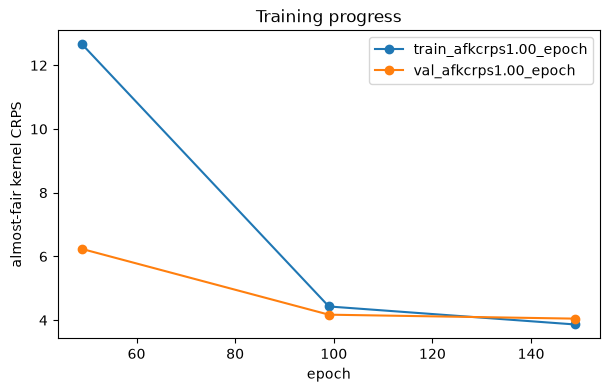

In [11]:
import mlflow, pandas as pd
import matplotlib.pyplot as plt

tracking_uri = f"file:///home/{os.getenv('USER')}/anemoi-output/logs/mlflow"
client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)

# Grab the most recent run in our experiment
exp = client.get_experiment_by_name(f"{os.getenv('USER')}-ens-training")
run = client.search_runs([exp.experiment_id], order_by=["attribute.start_time DESC"], max_results=1)[0]
run_id = run.info.run_id
print("Latest run:", run_id)

fig, ax = plt.subplots(figsize=(7, 4))
for metric in ["train_afkcrps1.00_epoch", "val_afkcrps1.00_epoch"]:
    hist = client.get_metric_history(run_id, metric)
    if hist:
        hist = sorted(hist, key=lambda h: h.step)
        ax.plot([h.step for h in hist], [h.value for h in hist], "-o", label=metric)
ax.set_xlabel("epoch"); ax.set_ylabel("almost-fair kernel CRPS"); ax.legend(); ax.set_title("Training progress")
plt.show()

#### Task 3 (optional) — train for longer, or with more members

Re-run Part 2 with a bigger budget and see how the forecast in Part 3 changes:

- increase `MAX_STEPS` (e.g. to 500) and/or `ENSEMBLE_SIZE` (e.g. to 4) above
- re-write the config
- re-run the training cell;

How does the validation CRPS change for the same number of steps? How much slower is each step with more members? At what point do you stop seeing improvement?

You do not have to run this operation inside the notebook. You can launch it from a terminal with
`anemoi-training train --config-name my_ens_config`.

# Part 3 · Forecast today's weather with your checkpoint (`anemoi-inference`)

### Under the hood: autoregressive inference

The training we just ran produced an *inference checkpoint* — the weights plus all the metadata `anemoi-inference` needs: which variables the model consumes and produces, the encoder/decoder graph, and the normalisation statistics. This checkpoint was created because the default Anemoi configs enable it (see `configs/diagnostics/evaluation.yaml`: it sets `enable_checkpointing: True` and a `checkpoint:` schedule that saves every epoch and writes the inference checkpoint). `anemoi-inference`'s `SimpleRunner` reads all of this from the checkpoint, so at inference time you only have to supply the initial conditions.

The runner then rolls the model forward autoregressively: it normalises your inputs, predicts +6 h, feeds that back in for +12 h, and so on. It computes the time-dependent forcings (solar insolation, date encodings) itself for each step, and, because this is an ensemble model, injects noise on every run, so repeated runs give different members.

Unlike the held-out data used in training, we will initialise from real, current analysis fields from ECMWF open data. Rather than a validation during training, this is therefore more akin to an evaluation of the model we trained, on data far outside the training envelope.

### Find your checkpoint

In [12]:
from pathlib import Path

# anemoi-training writes checkpoints under <output>/checkpoint/<run-hash>/.
ckpt_root = Path(f"/home/{os.getenv('USER')}/anemoi-output/checkpoint")
CKPT = max(ckpt_root.glob("*/inference-last.ckpt"), key=lambda p: p.stat().st_mtime)
print("Using checkpoint:", CKPT)

from anemoi.inference.checkpoint import Checkpoint
ck = Checkpoint(str(CKPT))
import warnings; warnings.filterwarnings("ignore")
print("prognostic variables:", ck.prognostic_variables)
print("diagnostic variables:", ck.diagnostic_variables)

Using checkpoint: /home/user/anemoi-output/checkpoint/<run>/inference-last.ckpt
prognostic variables: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250']
diagnostic variables: ['cp', 'tp']


### Get initial conditions from ECMWF open data

The model needs the state at two consecutive times (it uses a 2-step input, `t-6h` and `t`). Just like for modules 4 and 5, we fetch those from ECMWF [open data](https://www.ecmwf.int/en/forecasts/datasets/open-data). The data comes on a regular 0.25° grid, so we regrid it to the model's O96 grid with `earthkit-regrid`.

Two details worth noting:
- open data provides geopotential height `gh`; the model was trained on geopotential `z`, so we convert with `z = gh · g`;
- we request the surface fields with `levtype="sfc"` so that `z`/`lsm`/`sdor`/`slor` come back as single surface fields (not pressure levels).

In [13]:
import datetime
from collections import defaultdict
import numpy as np
import earthkit.data as ekd
import earthkit.regrid as ekr
from ecmwf.opendata import Client as OpendataClient

GRID_RESOLUTION = "O96"
PARAM_SFC = ["2t", "z", "lsm", "tcw", "sdor", "slor"]
PARAM_PL  = ["gh", "t"]
LEVELS    = [1000, 850, 700, 500, 300, 250]

DATE = OpendataClient().latest()
print("Latest available initial date:", DATE)

def get_open_data(param, levelist=[], reference_date=DATE, **kwargs):
    fields = defaultdict(list)
    for date in [reference_date - datetime.timedelta(hours=6), reference_date]:  # t-6h and t
        data = ekd.from_source("ecmwf-open-data", date=date, param=param, levelist=levelist, **kwargs)
        for f in data:
            values = np.roll(f.to_numpy(), -f.shape[1] // 2, axis=1)              # shift -180..180 -> 0..360
            values = ekr.interpolate(values, {"grid": (0.25, 0.25)}, {"grid": GRID_RESOLUTION})  # 0.25 deg -> O96
            name = f"{f.metadata('param')}_{f.metadata('levelist')}" if levelist else f.metadata("param")
            fields[name].append(values)
    return {p: np.stack(v) for p, v in fields.items()}

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


Latest available initial date: 2026-07-13 06:00:00


In [14]:
fields = {}
fields.update(get_open_data(param=PARAM_SFC, levtype="sfc"))     # surface fields
fields.update(get_open_data(param=PARAM_PL, levelist=LEVELS))    # pressure-level fields

# geopotential height -> geopotential
for level in LEVELS:
    gh = fields.pop(f"gh_{level}")
    fields[f"z_{level}"] = gh * 9.80665

# keep only the fields the model takes as input (forcings are computed by the runner)
model_inputs = ["z_1000", "z_500", "z_700", "z_300", "2t", "t_850", "tcw", "z_250", "lsm", "z", "sdor", "slor"]
fields = {k: v for k, v in fields.items() if k in model_inputs}

input_state = dict(date=DATE, fields=fields)
print("input fields:", sorted(fields))
print("each field shape (2 times, gridpoints):", fields["2t"].shape)

<multiple>:   0%|          | 0.00/3.44M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


<multiple>:   0%|          | 0.00/3.44M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/5.87M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/5.86M [00:00<?, ?B/s]

input fields: ['2t', 'lsm', 'sdor', 'slor', 't_850', 'tcw', 'z', 'z_1000', 'z_250', 'z_300', 'z_500', 'z_700']
each field shape (2 times, gridpoints): (2, 40320)


### Run the forecast

We roll the model forward `LEAD_TIME` hours. Because the model is stochastic, we run it a few times to build a small ensemble. Each pass injects different noise and so gives a different member.

In [15]:
import copy
from anemoi.inference.runners.simple import SimpleRunner

runner = SimpleRunner(str(CKPT))

LEAD_TIME = 48        # hours
ENS_MEMBERS = 4       # each run is a different member (different internal noise)

members = []
for m in range(ENS_MEMBERS):
    states = [copy.deepcopy(s) for s in runner.run(input_state=input_state, lead_time=LEAD_TIME)]
    members.append(states)
print(f"Generated {ENS_MEMBERS} members, each with {len(members[0])} forecast steps "
      f"(valid up to {members[0][-1]['date']}).")

Old metadata format detected. Please update your weights.


Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'z']


Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'z']


Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'z']


Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'z']


Generated 4 members, each with 8 forecast steps (valid up to 2026-07-15 06:00:00).


### Inspect the forecast: 2 m temperature

We plot the ensemble-mean 2 m temperature at the final lead time, globally and over Europe.

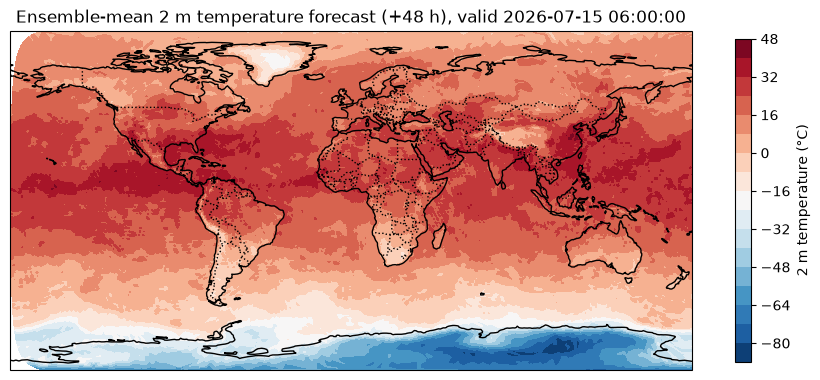

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.tri as tri

def fix(lons): return np.where(lons > 180, lons - 360, lons)

final = [mem[-1] for mem in members]
lat = final[0]["latitudes"]; lon = fix(final[0]["longitudes"])
t2m_mean = np.mean([s["fields"]["2t"] for s in final], axis=0) - 273.15   # ensemble mean, degC
valid = final[0]["date"]
trig = tri.Triangulation(lon, lat)

fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=":")
cf = ax.tricontourf(trig, t2m_mean, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu_r")
fig.colorbar(cf, ax=ax, shrink=0.7, label="2 m temperature (°C)")
ax.set_title(f"Ensemble-mean 2 m temperature forecast (+{LEAD_TIME} h), valid {valid}")
plt.show()

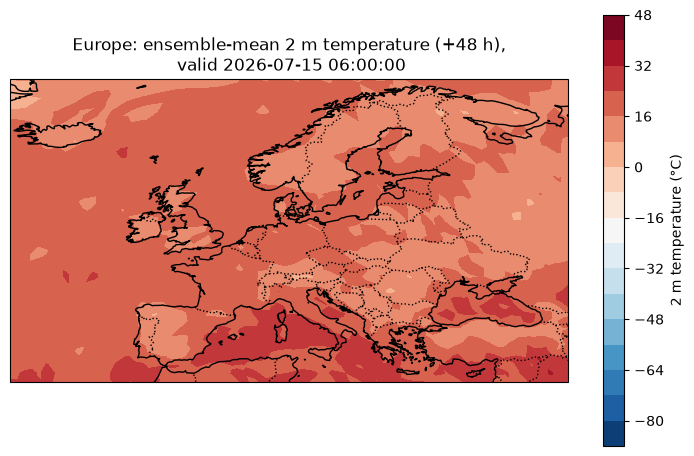

In [17]:
fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-25, 45, 34, 72], crs=ccrs.PlateCarree())
ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=":")
cf = ax.tricontourf(trig, t2m_mean, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu_r")
fig.colorbar(cf, ax=ax, shrink=0.8, label="2 m temperature (°C)")
ax.set_title(f"Europe: ensemble-mean 2 m temperature (+{LEAD_TIME} h),\n valid {valid}")
plt.show()

### Ensemble spread at a point

For a single location, the spread across members is a first, crude measure of forecast uncertainty. With only a handful of members and a toy model, read this qualitatively.

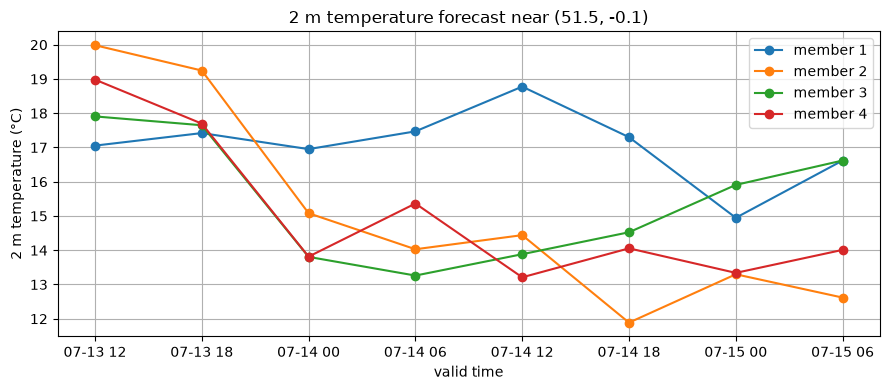

In [18]:
from helpers import find_nearest_point_index
import pandas as pd

lat_t, lon_t = 51.5, -0.1   # London
idx = find_nearest_point_index(lat, lon, lat_t, lon_t)
times = pd.to_datetime([s["date"] for s in members[0]])

plt.figure(figsize=(9, 4))
for m, mem in enumerate(members):
    series = [s["fields"]["2t"][idx] - 273.15 for s in mem]
    plt.plot(times, series, marker="o", label=f"member {m+1}")
plt.title(f"2 m temperature forecast near ({lat_t}, {lon_t})")
plt.xlabel("valid time"); plt.ylabel("2 m temperature (°C)"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

### Discussion: is this a good forecast?

Look critically at the maps. A well-trained model reproduces sharp and realistic local detail. Our predictions are smooth and blurry. The forecasts also do not generalise: We trained the model on data from Jan-Feb (remember the date window selection above), so when you run it in Boreal summer, it will not have seen enough examples of summer climate in Europe to have learned how to translate the relevant forcings (e.g. insolation) into warmer temperatures at these locations. Here we ran the model in a week when a heatwave swept across Europe (maxima of 27-29°C); this model still predicted 12-17°C. We are also unlikely to have created a well-calibrated ensemble forecast; you may try to evaluate it with the tools from module 6 if you wish to make this explicit.

Nevertheless, you can notice how the temperature pattern is recognisable at the largest scales (warm tropics, cold poles, land–sea contrast), so the model has learned something physical and is on the right path; it just needs more data, a longer training and more weights.

This is of course the bitter lesson coming back: skill is bought with data and computing resources. If you did Task 3, compare that forecast with this one. To go further you would increase the dataset span, the model size (`num_channels`, `num_layers`), and the number of training steps by orders of magnitude — which is exactly what produces the operational AIFS you used in modules 4 and 5.

# Key takeaways

- We explored a typical three-stage Anemoi workflow: `anemoi-datasets` (build a training-ready zarr) → `anemoi-training` (fit the model) → `anemoi-inference` (forecast from real initial conditions).
- We created a training-ready dataset, as a single, chunked, statistics-annotated zarr; you can build one for your own purposes, e.g. by subsetting the public ERA5 catalogue with a recipe.
- The model is a graph-transformer: a GNN encoder/decoder around a transformer processor, forecasting one 6-hour step at a time.
- Ensemble/CRPS training in Anemoi Training uses `GraphEnsForecaster`, `DDPEnsGroupStrategy`, `AnemoiEnsModelEncProcDec`, the ensemble data module, and the `AlmostFairKernelCRPS` loss; members share weights, and differ through injected noise.
- Running your own checkpoint on today's weather makes the effect of a small data/compute budget visible; here we can just expose the workflows, and give a sense of the scale needed to train operational models.

**Where to go next:** We have just begun discovering Anemoi. To go further, you can start with the [Anemoi documentation](https://anemoi.readthedocs.io/), which offers recipes and/or documentation for multi-GPU training, larger graphs and datasets, diffusion-based models, and limited-area modelling.